## Agenda:

- differentiate the regression with classification under supervised learning(labelled data-i/p given a specified o/p)

 - Classification algorithm: Logistic regression and Naive Bayes(mathematical in nature)

## Recap

- Machine Learning:super,unsuper,reinforcement
- Supervised: Classification(putting into category),Regression(predicting numerical value).
  - Regression:Linear,polynomial
  - Classification:predicting a category an object falls under.

# What is Classification?

Classification in supervised learning is a technique where a model uses labelled training data to predict the categorical label for new data points.
is it cat or dog or camel we give and new one it predicts.

## Types based on no.of classes/labels and output structure

- **Binary classification**: Predicts one of the two possible class,like yes/no,positive/negative,spam/ham
-** Multi-class**: Assign the data point to one of the many mutually exclusive classes.Classifying an image as a cat or a ship or a bird or vegetable.
- **Multi label**: Allows assignment to multiple classes simultaneously, a movie can be genre action,thriller,comedy.
- **Imbalanced classification**: Handles data where one class dominates requiring special techniques to avoid bias towards the majority category. Our data is based on 90% students passed data only 10% abt failed so cant come to conclusion.so more data points or more students we have add only then entire school we can conclude

# Classification Algorithms

# 1. Logistic regression

## What is logistic regression

- Logistic regression is a ML supervised learning algorithm for classification.
- It is used mainly for binary classification.
- Despite its name, it performs classification rather than regression.
- We define a threshold line for the slowly increasing data with min and max so it classifies and below that 0 and above all 1, since only 2 options binary classification.


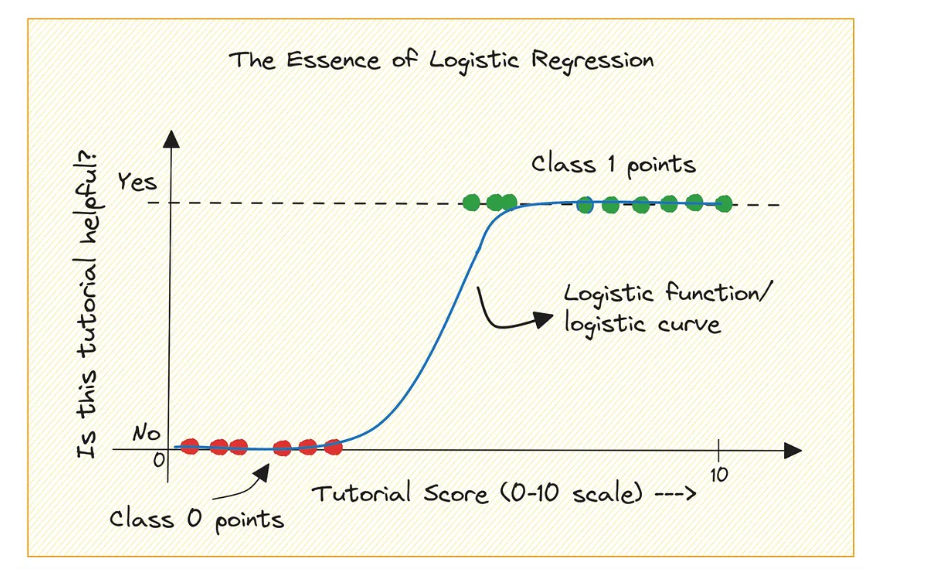

## Implement logistic regression for binary classification

### Step 1: Problem definition

Given measurements of breast mass,predict whether the tumor is malignant or benign.

### Step 2: Load and understand the data

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

data= load_breast_cancer(as_frame=True)
df=data.frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# no. of rows and columns
len(df)

569

In [ ]:
len(df.columns)

31

In [ ]:
# no.of unique categories in target--> to check if data is balanced or not
df['target'].nunique() #yes/no

2

In [ ]:
df['target'].value_counts() #how many # almost balanced

,count
target,
1,357
0,212


In [ ]:
# shape
df.shape

(569, 31)

In [ ]:
#general info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
# overall statistics
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
# are there missing values and duplicates
df.isnull().sum() # no missing values

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
df.duplicated().sum() # no duplicates

np.int64(0)

### Step 3: Preprocessing

In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# when using logistic regression---> no need for normal distribution
# Logistic regression: makes no assumption that the features must follow normal distribution as it follows logarithmic scale

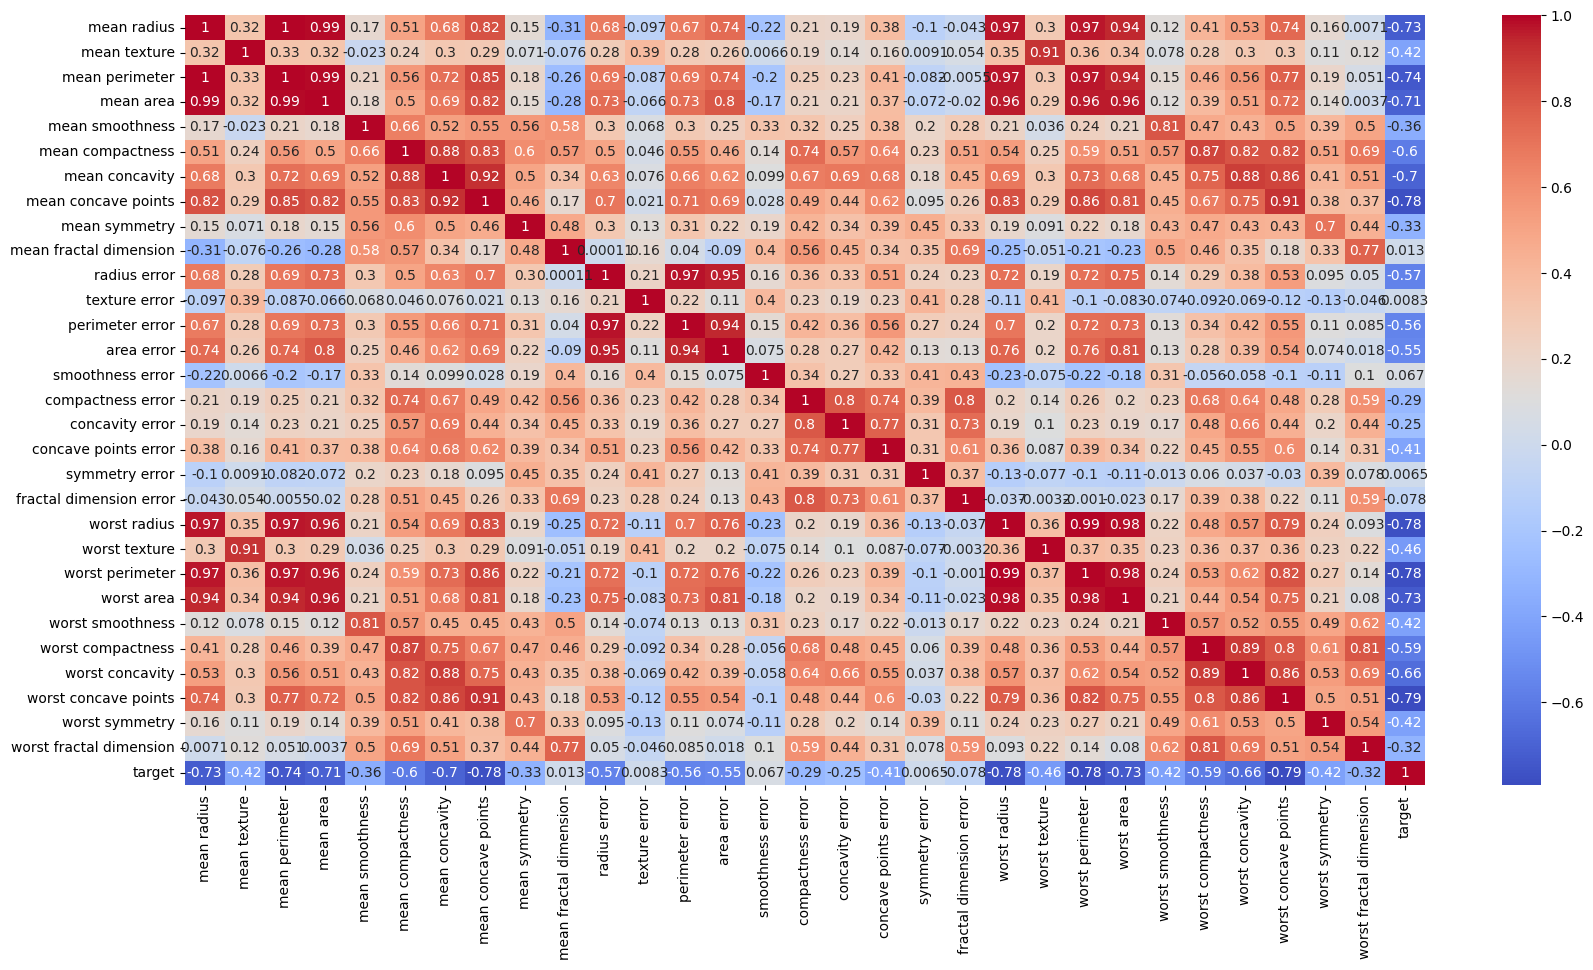

In [ ]:
# do bivariate analysis wrt target column to understand the data
# - strong predictors - correlation heat map
# As features: 30 in number # target: one single column
# if no of columns less box to check outliers,hist etc.. and if data demands scatter

# visualize to identify redundant features

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Feature correlation heatmap')
plt.show()

In [ ]:
# drop highly correlated features- model will get confused and only based on that it will tell # shd do pca before that
corr_matrix=df.corr()
upper=corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)) # now triu becomes true # the where indicates that upper df shd have only those values of corr matrix where it is true ie follows this pattern
# upper now has only upper triangular matrix stored in form of df
to_drop=[column for column in upper.columns if any(upper[column]>0.9)]
df_reduced=df.drop(columns=to_drop,axis=1)
df_reduced.head()

# reduced to 20 features
# this removes a lot of multi collinear features as logistic regression assumes features are all independent
# since model assumes features are independent and not linear with relationship it is necessary to reduce the no.of columns

,mean radius,mean texture,mean smoothness,mean compactness,mean concavity,mean symmetry,mean fractal dimension,radius error,texture error,smoothness error,...,concavity error,concave points error,symmetry error,fractal dimension error,worst smoothness,worst compactness,worst concavity,worst symmetry,worst fractal dimension,target
0,17.99,10.38,0.11840,0.27760,0.3001,0.2419,0.07871,1.0950,0.9053,0.006399,...,0.05373,0.01587,0.03003,0.006193,0.1622,0.6656,0.7119,0.4601,0.11890,0
1,20.57,17.77,0.08474,0.07864,0.0869,0.1812,0.05667,0.5435,0.7339,0.005225,...,0.01860,0.01340,0.01389,0.003532,0.1238,0.1866,0.2416,0.2750,0.08902,0
2,19.69,21.25,0.10960,0.15990,0.1974,0.2069,0.05999,0.7456,0.7869,0.006150,...,0.03832,0.02058,0.02250,0.004571,0.1444,0.4245,0.4504,0.3613,0.08758,0
3,11.42,20.38,0.14250,0.28390,0.2414,0.2597,0.09744,0.4956,1.1560,0.009110,...,0.05661,0.01867,0.05963,0.009208,0.2098,0.8663,0.6869,0.6638,0.17300,0
4,20.29,14.34,0.10030,0.13280,0.1980,0.1809,0.05883,0.7572,0.7813,0.011490,...,0.05688,0.01885,0.01756,0.005115,0.1374,0.2050,0.4000,0.2364,0.07678,0


In [ ]:
# already numerical- only scaling
# StandardScaler: better for logistic regression

#input dataframe : df_reduced
# no need to scale target as it has only yes/no cancer so only features
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df_scaled=scaler.fit_transform(df_reduced.drop('target',axis=1)) # this itself splits data df_scaled has all other features scaled

# after scaling the dataframe gets coverted to a numpy array
# convert back to df as can see head etc..

In [ ]:
# df_scaled:numpy array
# df_reduced: holds column names of only required

# convert the scaled array to DataFrame with featurenames as in array it will have only values

df_scaled=pd.DataFrame(df_scaled,columns=df_reduced.drop('target',axis=1).columns)

# add 'target' column with no scaling rest all normally distributed
df_scaled['target']=df_reduced['target']
df_scaled.head()

,mean radius,mean texture,mean smoothness,mean compactness,mean concavity,mean symmetry,mean fractal dimension,radius error,texture error,smoothness error,...,concavity error,concave points error,symmetry error,fractal dimension error,worst smoothness,worst compactness,worst concavity,worst symmetry,worst fractal dimension,target
0,1.097064,-2.073335,1.568466,3.283515,2.652874,2.217515,2.255747,2.489734,-0.565265,-0.214002,...,0.724026,0.660820,1.148757,0.907083,1.307686,2.616665,2.109526,2.750622,1.937015,0
1,1.829821,-0.353632,-0.826962,-0.487072,-0.023846,0.001392,-0.868652,0.499255,-0.876244,-0.605351,...,-0.440780,0.260162,-0.805450,-0.099444,-0.375612,-0.430444,-0.146749,-0.243890,0.281190,0
2,1.579888,0.456187,0.942210,1.052926,1.363478,0.939685,-0.398008,1.228676,-0.780083,-0.297005,...,0.213076,1.424827,0.237036,0.293559,0.527407,1.082932,0.854974,1.152255,0.201391,0
3,-0.768909,0.253732,3.283553,3.402909,1.915897,2.867383,4.910919,0.326373,-0.110409,0.689702,...,0.819518,1.115007,4.732680,2.047511,3.394275,3.893397,1.989588,6.046041,4.935010,0
4,1.750297,-1.151816,0.280372,0.539340,1.371011,-0.009560,-0.562450,1.270543,-0.790244,1.483067,...,0.828471,1.144205,-0.361092,0.499328,0.220556,-0.313395,0.613179,-0.868353,-0.397100,0


### Step 4: Train-Test split

In [ ]:
from sklearn.model_selection import train_test_split

x= df_scaled.drop('target',axis=1) # all features
y= df_scaled['target'] # the target

##          x(features)                 y(output category)
##
##      Training(75%)-->x_train         Training--> y_train
##      Testing(25%)-->x_test           test results--> y_test
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

print(x_train.shape,x_test.shape,y_train.shape,y_test.shape) # y_train 426 output of trained data

(426, 20) (143, 20) (426,) (143,)


### Step 5: Train the Logistic regression model

In [ ]:
from sklearn.linear_model import LogisticRegression

#instantiate the model
model=LogisticRegression()

# Training(fit) the model using my train data(features : x_train,y_train)
model.fit(x_train,y_train)

LogisticRegression()

### Step 6: Evaluation

In [ ]:
#make prediction on the test data after training is complete
# y_test actual data

y_pred= model.predict(x_test)

# predictions are stored: y_pred
# actual output are stored: y_test

In [ ]:
# for classification metrics: accuarcy as only yes/no no numerical so no r2 score or mse etc
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.972027972027972

In [ ]:
# other metrics for classification: precision,recall and F1 score
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        54
           1       0.99      0.97      0.98        89

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



In [ ]:
# metrics: roc_auc region under the curve
from sklearn.metrics import roc_auc_score

# predicted probabalities for class 1 # like measuring only the accuracy of only 1
yprob_a=model.predict_proba(x_test)[:,1] # all rows for second column only wrt 1 area under it only 1 column?

#ROC AUC score
roc_auc=roc_auc_score(y_test,yprob_a)

In [ ]:
roc_auc

np.float64(0.9950062421972534)

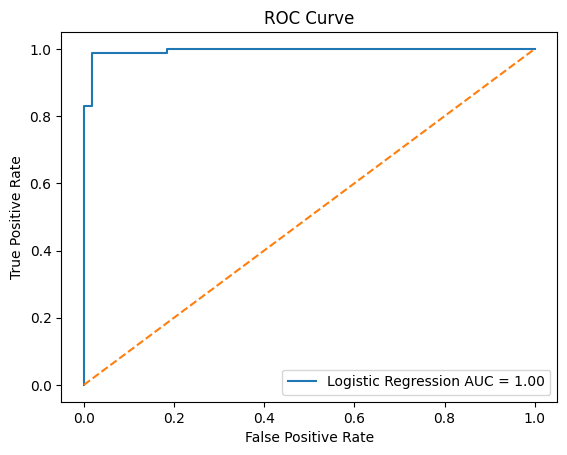

In [ ]:
# plot roc curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test,yprob_a) # direct usage wherever in place of 1 it gave 0 that is given by fpr and correctly said rate is tpr
plt.plot(fpr,tpr, label=f'Logistic Regression AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
# area under it can be taken

In [ ]:
from sklearn.metrics import precision_score,recall_score,f1_score
# given as list as works better
metric_df=pd.DataFrame({
    'Model':['Logistic Regression'],
    'Accuracy':[accuracy_score(y_test,y_pred)],
    'Precision':[precision_score(y_test,y_pred)],
    'Recall':[recall_score(y_test,y_pred)],
    'F1 score':[f1_score(y_test,y_pred)],
    'ROC AUC':[roc_auc]
})

metric_df

,Model,Accuracy,Precision,Recall,F1 score,ROC AUC
0,Logistic Regression,0.972028,0.988506,0.966292,0.977273,0.995006


In [ ]:
metric_df.round(4)

,Accuracy,Precision,Recall,F1 score,ROC AUC
0,0.972,0.9885,0.9663,0.9773,0.995


### Step 7: Interpret Results

- **Accuracy:** out of all the predictions,the model was correct 97.2% of times with actual data. How many correct answers when compared to the whole data is 1s and 0s actually 1 and 0 in the correct position

- **Precision:** when the model predicted positive(1),it was correct 98.85% of time the no.of times 1 appeared was also correct among themselves.Precision measures the quality of positive predictions (TP / (TP+FP)), asking "of those predicted positive, how many were correct?",

- **Recall:** Out of all the actual positives(1) samples, the model was able to catch 96% of them. was the actual 1 said as 1 only and not 0.Recall (Sensitivity) measures how many actual positives were found (TP / (TP+FN)), answering "of all actual positives, how many did we catch?".

- **F1 score:** Harmonic mean between Precison and Recall.Extremely high of 97.73%.The model is very strong in predicting class 1. using formula

- **ROC AUC:** measures how well the model separates class 0 and class 1 across all probability thresholds.0.995---> almost perfect class separation. how well 0 is separated from 1 in its memory or taining

In [ ]:
# lets check the confusion matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_pred)

array([[53,  1],
       [ 3, 86]])

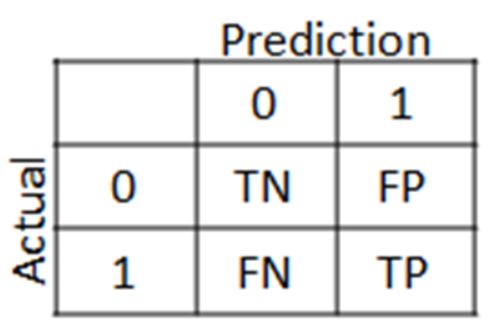

143 test data

139/143*100 = 97.2 - accuracy

# Classification algorithm 2: Naive Bayes

- Naive(innocent) Bayes is probablistic classifier based on Bayes theorem.not that much for real datasets but works well also
- based on conditional probability given the class label.
- Assumes that all features are independant


In [ ]:
# what we have: x train,y train,xtest and ytest

#import and train the naive bayes algorithm on our training data
from sklearn.naive_bayes import GaussianNB
gnb=GaussianNB()
gnb.fit(x_train,y_train)

GaussianNB()

In [ ]:
# make predictions on the test set and store the results in y_pred_nb
y_pred_nb=gnb.predict(x_test)

In [ ]:
# Evaluation metrics for Gaussian nb

nb_row={
    'Model':['Naive Bayes'],
    'Accuracy':[accuracy_score(y_test,y_pred)],
    'Precision':[precision_score(y_test,y_pred)],
    'Recall':[recall_score(y_test,y_pred)],
    'F1 score':[f1_score(y_test,y_pred)],
    'ROC AUC': roc_auc
}

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
metric_df.loc[1]=['Naive Bayes',
                  accuracy_score(y_test,y_pred_nb),
                  precision_score(y_test,y_pred_nb),
                  recall_score(y_test,y_pred_nb),
                  f1_score(y_test,y_pred_nb),
                  roc_auc_score(y_test,y_pred_nb)]
metric_df
# here LR better than NB

,Model,Accuracy,Precision,Recall,F1 score,ROC AUC
0,Logistic Regression,0.972028,0.988506,0.966292,0.977273,0.995006
1,Naive Bayes,0.930070,0.943820,0.943820,0.943820,0.925614
